<a href="https://colab.research.google.com/github/penajuanmanuel6-hub/automated-etl-pipeline/blob/main/Logistica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  zona_destino  peso_kg
0        Norte     1220
1    Occidente     1150


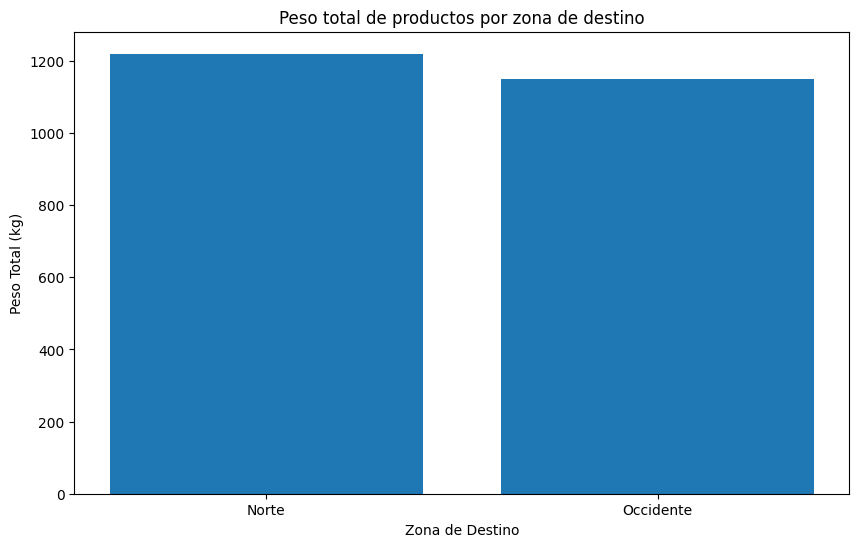

In [10]:
#Ejercicio de Logística

import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

datos=pd.DataFrame({"id_despacho": [101, 102, 103, 104, 105, 106],
    "zona_destino": ['Norte', 'Norte', 'Occidente', 'Occidente', 'Norte', 'Occidente'],
    "peso_kg": [400, 500, 450, 300, 320, 400]})

#Configuración y Conexión (Raíz)
def connect():
  engine=sqlite3.connect(":memory:")
  return engine

#Extracción de datos con SQL (Rama)
def extraer_datos(query,conexion):
  df_resultado=pd.read_sql(query,conexion)
  return df_resultado

#Limpieza y transformación de datos (Ramas)
def limpiar_datos(df):
  df=df.drop_duplicates()
  df["peso_kg"]=df.groupby("zona_destino")["peso_kg"].transform(lambda x: x.fillna(x.median))
  return df

#Generar reporte (hojas y frutos)
def generar_reporte(df):
  resumen=df.groupby("zona_destino")["peso_kg"].sum().reset_index()
  print(resumen)
  return resumen

#Orquestación (Tronco)
if __name__=="__main__":
  conexion=connect()
  datos.to_sql("datos", conexion, if_exists="replace", index=False)
  sql="SELECT * FROM datos;"
  df_crudos=extraer_datos(sql,conexion)
  df_limpios=limpiar_datos(df_crudos)
  resumen=generar_reporte(df_limpios)

plt.figure(figsize=(10,6))
plt.bar(resumen["zona_destino"], resumen["peso_kg"])
plt.xlabel("Zona de Destino")
plt.ylabel("Peso Total (kg)")
plt.title("Peso total de productos por zona de destino")
plt.show()



